In [9]:
# from huggingface_hub import list_repo_files, hf_hub_download
# import os

# REPO_ID = "philipphager/baidu-ultr_uva-mlm-ctr"
# DATA_DIR = "./baidu_ultr_dataset"

# os.makedirs(DATA_DIR, exist_ok=True)

# # List files from a DATASET repo
# files = list_repo_files(REPO_ID, repo_type="dataset")

# print(f"Found {len(files)} files.")

# for file in files:
#     # Skip loading script
#     if file.endswith(".py") or file.endswith(".md"):
#         continue

#     print("Downloading:", file)
#     hf_hub_download(
#         repo_id=REPO_ID,
#         repo_type="dataset",            # IMPORTANT
#         filename=file,
#         local_dir=DATA_DIR,
#         local_dir_use_symlinks=False,
#         resume_download=True,
#     )

# print("Done.")


Found 44 files.
Downloading: .gitattributes


/opt/homebrew/Caskroom/miniforge/base/envs/two-tower-confounding-2/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:186: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/two-tower-confounding-2/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Downloading: parts/part-0_split-0.feather
Downloading: parts/part-0_split-1.feather
Downloading: parts/part-0_split-2.feather
Downloading: parts/part-0_split-3.feather
Downloading: parts/part-0_split-4.feather
Downloading: parts/part-0_split-5.feather
Downloading: parts/part-0_split-6.feather
Downloading: parts/part-0_split-7.feather
Downloading: parts/part-0_split-8.feather
Downloading: parts/part-0_split-9.feather
Downloading: parts/part-1_split-0.feather
Downloading: parts/part-1_split-1.feather
Downloading: parts/part-1_split-2.feather
Downloading: parts/part-1_split-3.feather
Downloading: parts/part-1_split-4.feather
Downloading: parts/part-1_split-5.feather
Downloading: parts/part-1_split-6.feather
Downloading: parts/part-1_split-7.feather
Downloading: parts/part-1_split-8.feather
Downloading: parts/part-1_split-9.feather
Downloading: parts/part-2_split-0.feather
Downloading: parts/part-2_split-1.feather
Downloading: parts/part-2_split-2.feather
Downloading: parts/part-2_split-3.

In [49]:
import os
os.listdir("./baidu_ultr_dataset/parts")

FileNotFoundError: [Errno 2] No such file or directory: './baidu_ultr_dataset/parts'

In [1]:
import pyarrow.feather as feather
import pyarrow as pa
import glob

FEATHER_DIR = "../baidu_ultr_dataset/parts"

# ---------------------------------------------------------
# Get complete list of columns from the first feather file
# ---------------------------------------------------------
sample_file = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))[0]
sample_table = feather.read_table(sample_file)

# Remove ONLY the embedding column
columns = [c for c in sample_table.column_names if c != "query_document_embedding"]

# ---------------------------------------------------------
# Load all files with the filtered column list
# ---------------------------------------------------------
paths = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))
# remove all with part-0 in the name
paths = [p for p in paths if "part-0" not in p]

tables = []
for path in paths:
    print("Loading:", path)
    table = feather.read_table(path, columns=columns)  # all except embedding
    tables.append(table)

# Merge into a single big arrow table
ltr_table = pa.concat_tables(tables, promote=True)

print(ltr_table)


Loading: ../baidu_ultr_dataset/parts/part-1_split-0.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-1.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-2.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-3.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-4.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-5.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-6.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-7.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-8.feather
Loading: ../baidu_ultr_dataset/parts/part-1_split-9.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-0.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-1.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-2.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-3.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-4.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-5.feather
Loading: ../baidu_ultr_dataset/parts/par

/opt/homebrew/Caskroom/miniforge/base/envs/two-tower-confounding-2/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: FutureWarning: promote has been superseded by promote_options='default'.
  exec(code_obj, self.user_global_ns, self.user_ns)


[
  [
    1,
    2,
    3,
    4,
    6,
    ...
    13,
    14,
    1,
    2,
    4
  ],
  [
    5,
    6,
    7,
    8,
    9,
    ...
    8,
    9,
    1,
    2,
    3
  ],
...,
  [
    4,
    5,
    6,
    7,
    8,
    ...
    6,
    7,
    8,
    9,
    3
  ],
  [
    5,
    7,
    8,
    9,
    1,
    ...
    2,
    6,
    7,
    8,
    9
  ]
]

In [56]:
len(ltr_table["query_id"].unique())

1779017

In [19]:
ltr_table["click"].unique()

[
  0,
  1
]

In [18]:
len(ltr_table["query_no"].unique())

593930

Feature: position, Unique permutations: 22
Feature: media_type, Unique permutations: 609
Feature: displayed_time, Unique permutations: 292140
Feature: serp_height, Unique permutations: 1818
Feature: slipoff_count_after_click, Unique permutations: 53


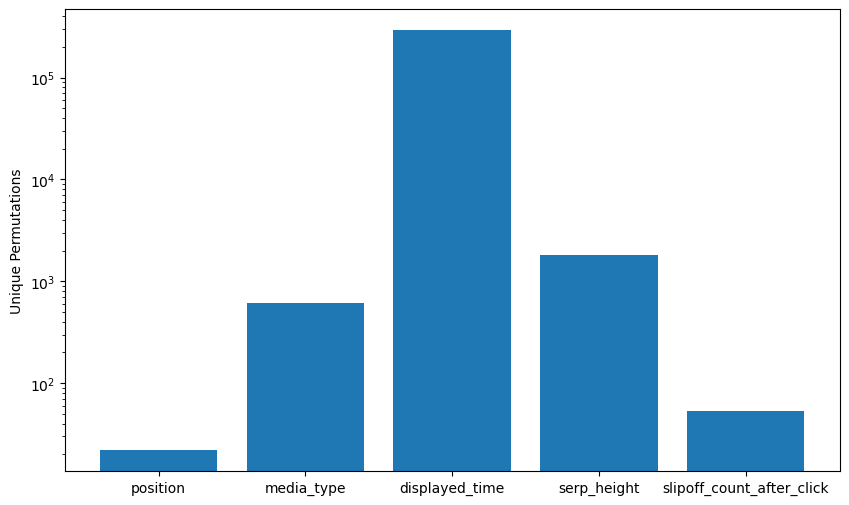

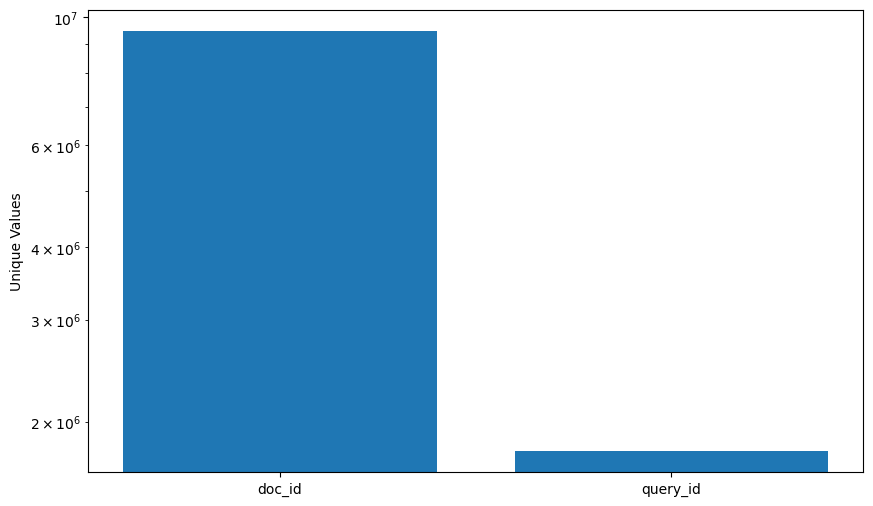

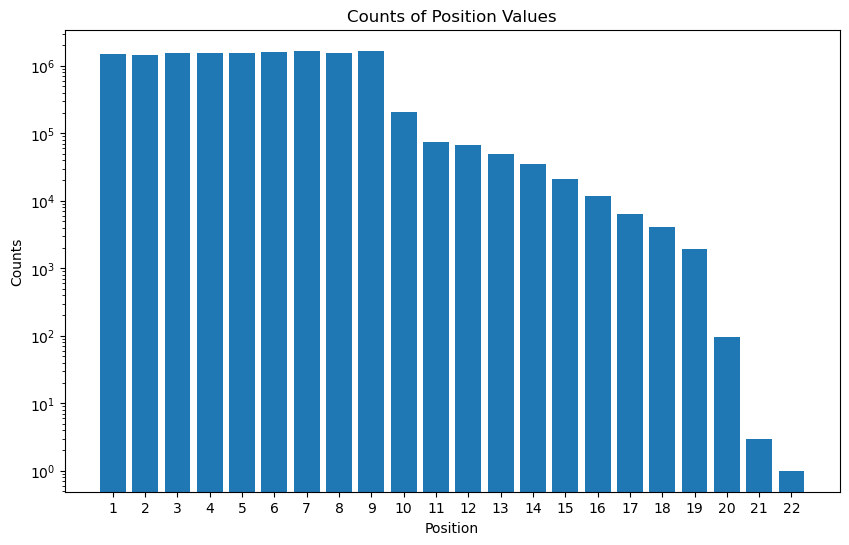

In [65]:
# Position bias features
# "position": Sequence(Value("int32")),
# "media_type": Sequence(Value("int32")),
# "displayed_time": Sequence(Value("float32")),
# "serp_height": Sequence(Value("int32")),
# "slipoff_count_after_click": Sequence(Value("int32")),
position_bias_features = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]

# count how many different position bias permutations there are per category, make a barplot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
feature_counts = {}
for feature in position_bias_features:
    counts = len(ltr_table[feature].unique().to_pylist())
    print(f"Feature: {feature}, Unique permutations: {counts}")
    feature_counts[feature] = counts

plt.bar(feature_counts.keys(), feature_counts.values(), log=True)

plt.ylabel("Unique Permutations")
plt.show()
    

doc_id = "url_md5"
query_id = "query_id"

plt.figure(figsize=(10, 6))
plt.bar(["doc_id", "query_id"], [len(ltr_table[doc_id].unique()), len(ltr_table[query_id].unique())], log=True)
plt.ylabel("Unique Values")
plt.show()
import matplotlib.pyplot as plt

counts = ltr_table["position"].value_counts()

counts = ltr_table["position"].value_counts()

pos_np = np.array(ltr_table["position"].to_numpy())

# Get unique values and their counts
unique_vals, counts = np.unique(pos_np, return_counts=True)

plt.figure(figsize=(10, 6))
plt.bar(unique_vals.astype(str), counts, log=True)
plt.ylabel("Counts")
plt.xlabel("Position")
plt.title("Counts of Position Values")
plt.show()

In [6]:
import pyarrow.feather as feather
import pyarrow as pa
import glob

FEATHER_DIR = "../baidu_ultr_dataset/parts"

# ---------------------------------------------------------
# Get complete list of columns from the first feather file
# ---------------------------------------------------------
sample_file = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))[0]
sample_table = feather.read_table(sample_file)

# Remove ONLY the embedding column
columns = [c for c in sample_table.column_names if c != "query_document_embedding"]

# ---------------------------------------------------------
# Load all files with the filtered column list
# ---------------------------------------------------------
paths = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))
# remove all with part-0 in the name
paths = [p for p in paths if "part-0" in p]

tables = []
for path in paths:
    print("Loading:", path)
    table = feather.read_table(path, columns=columns)  # all except embedding
    tables.append(table)

# Merge into a single big arrow table
ltr_table = pa.concat_tables(tables, promote=True)

print(ltr_table)


Loading: ../baidu_ultr_dataset/parts/part-0_split-0.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-1.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-2.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-3.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-4.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-5.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-6.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-7.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-8.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-9.feather
pyarrow.Table
query_no: int64
query_id: string
query_md5: string
url_md5: string
text_md5: string
query: list<item: int64>
  child 0, item: int64
title: list<item: int64>
  child 0, item: int64
abstract: list<item: int64>
  child 0, item: int64
position: int64
media_type: int64
displayed_time: double
serp_height: int64
slipoff_count_after_click: int64
click: int64
bm25: double
bm25_title: double
b

/opt/homebrew/Caskroom/miniforge/base/envs/two-tower-confounding-2/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: FutureWarning: promote has been superseded by promote_options='default'.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [7]:
ltr_table.column_names

['query_no',
 'query_id',
 'query_md5',
 'url_md5',
 'text_md5',
 'query',
 'title',
 'abstract',
 'position',
 'media_type',
 'displayed_time',
 'serp_height',
 'slipoff_count_after_click',
 'click',
 'bm25',
 'bm25_title',
 'bm25_abstract',
 'tf_idf',
 'tf',
 'idf',
 'ql_jelinek_mercer_short',
 'ql_jelinek_mercer_long',
 'ql_dirichlet',
 'query_length',
 'document_length',
 'title_length',
 'abstract_length',
 '__index_level_0__']

In [8]:
ltr_table['query'][0]

<pyarrow.ListScalar: [4251, 5875, 3482, 12641, 2972, 8478, 16799]>

In [9]:
501215

501215

In [10]:
print(len(ltr_table['query_no'].unique()))
print(len(ltr_table['query_id'].unique()))
print(len(ltr_table['query_md5'].unique()))


593930
593930
501215


In [11]:
# import numpy as np
# import pyarrow as pa

# # Extract arrays
# query_no = ltr_table["query_no"].to_numpy()
# positions = ltr_table["position"].to_numpy() - 1  # zero-based positions
# clicks = ltr_table["click"].to_numpy()

# # STEP 2: Find where each group begins
# unique_sessions, start_idx = np.unique(query_no, return_index=True)

# # Add end index
# end_idx = np.append(start_idx[1:], len(query_no))

# # Build ragged views (list of arrays) for later per-session needs
# all_positions = [positions[s:e] for s, e in zip(start_idx, end_idx)]
# all_clicks    = [clicks[s:e]    for s, e in zip(start_idx, end_idx)]
# all_sessions  = unique_sessions  # already correct

# # Fast check: determine sessions where observed_len != max_pos+1 (internal gaps)
# obs_lens = np.array([arr.size for arr in all_positions], dtype=np.int32)
# max_positions = np.array([int(arr.max()) if arr.size>0 else -1 for arr in all_positions], dtype=np.int32)
# has_internal_gaps = (obs_lens != (max_positions + 1)) & (obs_lens > 0)

# print(f"Total sessions: {len(all_positions)}")
# print(f"Sessions with internal missing positions: {np.sum(has_internal_gaps)}")
# gap_indices = np.nonzero(has_internal_gaps)[0]
# if gap_indices.size:
#     print("Examples (session_index, observed_len, max_pos):")
#     for idx in gap_indices[:10]:
#         print(idx, obs_lens[idx], max_positions[idx])

# # Vectorized internal padding approach:
# # Idea: for sessions without internal gaps keep original arrays; for sessions with gaps, create an array length (max_pos+1) and scatter values into it.
# # We'll create a 2D result by computing each session's length and filling using advanced indexing but avoid explicit Python loops over sessions where possible.

# # Compute target lengths per session (after internal padding)
# target_lengths = np.where(obs_lens>0, max_positions + 1, 0)
# max_len = target_lengths.max()
# num_sessions = len(all_positions)

# # Build flat arrays for advanced scatter:
# # We'll create flattened arrays that represent the per-session rows concatenated, then reshape into (num_sessions, max_len).
# row_offsets = np.concatenate([[0], np.cumsum(target_lengths)[:-1]]).astype(np.int64)  # start offset for each session in flat array
# total_cells = int(row_offsets[-1] + target_lengths[-1]) if target_lengths.size else 0

# flat_positions = np.full(total_cells, -1, dtype=np.int32)
# flat_clicks = np.zeros(total_cells, dtype=np.int8)

# # For sessions without gaps, we can copy their arrays directly into the flat arrays at the computed offsets.
# for i, (pos_arr, clk_arr) in enumerate(zip(all_positions, all_clicks)):
#     L = pos_arr.size
#     if L == 0:
#         continue
#     offset = row_offsets[i]
#     # If no internal gap and L == target_lengths[i], copy directly using slice
#     if L == target_lengths[i]:
#         flat_positions[offset:offset+L] = pos_arr
#         flat_clicks[offset:offset+L] = clk_arr
#     else:
#         # Need to scatter: positions are indices within [0, max_pos] where values should go
#         max_p = target_lengths[i]
#         # create temporary arrays for this session and scatter
#         tmp_pos = np.full(max_p, -1, dtype=np.int32)
#         tmp_clk = np.zeros(max_p, dtype=np.int8)
#         tmp_pos[pos_arr] = pos_arr
#         tmp_clk[pos_arr] = clk_arr
#         flat_positions[offset:offset+max_p] = tmp_pos
#         flat_clicks[offset:offset+max_p] = tmp_clk

# # Reshape flat arrays into (num_sessions, max_len) by filling rows with -1/0 where target_lengths are shorter than max_len
# padded_positions = np.full((num_sessions, max_len), -1, dtype=np.int32)
# padded_clicks = np.zeros((num_sessions, max_len), dtype=np.int8)

# for i in range(num_sessions):
#     L = target_lengths[i]
#     if L == 0:
#         continue
    
#     off = row_offsets[i]
#     padded_positions[i, :L] = flat_positions[off:off+L]
#     padded_clicks[i, :L] = flat_clicks[off:off+L]

# print('Final padded_positions.shape:', padded_positions.shape)
# print('Final padded_clicks.shape:   ', padded_clicks.shape)
# print('Num sessions with internal gaps:', np.sum(has_internal_gaps))

Total sessions: 593930
Sessions with internal missing positions: 353596
Examples (session_index, observed_len, max_pos):
2 9 9
3 7 8
4 7 8
5 8 8
6 7 8
8 8 8
9 7 8
11 8 8
12 8 8
13 5 8
Final padded_positions.shape: (593930, 21)
Final padded_clicks.shape:    (593930, 21)
Num sessions with internal gaps: 353596


In [12]:
# import numpy as np
# import pyarrow as pa

# # Extract arrays from pyarrow table
# query_no = ltr_table["query_no"].to_numpy()
# positions = ltr_table["position"].to_numpy() - 1  # zero-based positions
# clicks = ltr_table["click"].to_numpy()
# query_md5 = ltr_table["query_md5"].to_numpy()

# # Find where each session begins and ends
# unique_sessions, start_idx = np.unique(query_no, return_index=True)
# end_idx = np.append(start_idx[1:], len(query_no))

# # Build ragged lists for positions and clicks
# all_positions = [positions[s:e] for s, e in zip(start_idx, end_idx)]
# all_clicks    = [clicks[s:e]    for s, e in zip(start_idx, end_idx)]
# all_sessions  = unique_sessions

# # Compute observed lengths and max positions
# obs_lens = np.array([arr.size for arr in all_positions], dtype=np.int32)
# max_positions = np.array([int(arr.max()) if arr.size>0 else -1 for arr in all_positions], dtype=np.int32)

# # Target lengths per session (internal padding)
# target_lengths = np.where(obs_lens>0, max_positions + 1, 0)
# num_sessions = len(all_positions)
# max_len = target_lengths.max()

# # Flatten arrays with scatter to handle internal gaps
# row_offsets = np.concatenate([[0], np.cumsum(target_lengths)[:-1]]).astype(np.int64)
# total_cells = int(row_offsets[-1] + target_lengths[-1]) if target_lengths.size else 0

# flat_positions = np.full(total_cells, -1, dtype=np.int32)
# flat_clicks = np.zeros(total_cells, dtype=np.int8)

# for i, (pos_arr, clk_arr) in enumerate(zip(all_positions, all_clicks)):
#     L = pos_arr.size
#     offset = row_offsets[i]
#     # If no internal gap and L == target_lengths[i], copy directly
#     if L == target_lengths[i]:
#         flat_positions[offset:offset+L] = pos_arr
#         flat_clicks[offset:offset+L] = clk_arr
#     else:
#         max_p = target_lengths[i]
#         tmp_pos = np.full(max_p, -1, dtype=np.int32)
#         tmp_clk = np.zeros(max_p, dtype=np.int8)
#         tmp_pos[pos_arr] = pos_arr
#         tmp_clk[pos_arr] = clk_arr
#         flat_positions[offset:offset+max_p] = tmp_pos
#         flat_clicks[offset:offset+max_p] = tmp_clk

# # Reshape flat arrays to padded arrays
# padded_positions = np.full((num_sessions, max_len), -1, dtype=np.int32)
# padded_clicks    = np.zeros((num_sessions, max_len), dtype=np.int8)

# for i in range(num_sessions):
#     L = target_lengths[i]
#     off = row_offsets[i]
#     padded_positions[i, :L] = flat_positions[off:off+L]
#     padded_clicks[i, :L] = flat_clicks[off:off+L]

# # Build mask: 1 if real, 0 if padded
# mask = (padded_positions >= 0).astype(np.int8)

# # Sessions per query: based on query_md5
# session_query_md5 = np.array([query_md5[s:e][0] for s, e in zip(start_idx, end_idx)])
# unique_queries, query_counts = np.unique(session_query_md5, return_counts=True)
# query_to_count = dict(zip(unique_queries, query_counts))
# sessions_per_query = np.array([query_to_count[q] for q in session_query_md5], dtype=np.int32)

# # Sessions per doc_pos: count how many sessions observed a doc at this position
# sessions_per_doc_pos = np.zeros((num_sessions, max_len, max_len), dtype=np.int32)
# for i in range(num_sessions):
#     pos = padded_positions[i]
#     L = np.sum(mask[i])
#     sessions_per_doc_pos[i, np.arange(L), pos[:L]] = 1

# # Placeholder arrays for query-aligned features (replace with real RatingDataset)
# query_doc_features = np.zeros((num_sessions, max_len, 128), dtype=np.float32)  # 128 = example feature dim
# query_doc_ids      = np.zeros((num_sessions, max_len), dtype=np.int64)
# labels             = padded_clicks.copy()
# n                  = np.ones(num_sessions, dtype=np.int32)

# # All aligned arrays ready for ClickDataset
# print("padded_positions:", padded_positions.shape)
# print("padded_clicks:   ", padded_clicks.shape)
# print("mask:            ", mask.shape)
# print("sessions_per_query:", sessions_per_query.shape)
# print("sessions_per_doc_pos:", sessions_per_doc_pos.shape)


padded_positions: (593930, 21)
padded_clicks:    (593930, 21)
mask:             (593930, 21)
sessions_per_query: (593930,)
sessions_per_doc_pos: (593930, 21, 21)


In [13]:
# import numpy as np

# # num_sessions, max_len from padded_positions
# num_sessions, max_len = padded_positions.shape

# # ------------------------------
# # 1️⃣ Logging policy features
# # ------------------------------
# lp_feature_names = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]
# lp_features_arr = np.stack([ltr_table[name].to_numpy() for name in lp_feature_names], axis=1)  # shape (N_total, 5)

# # Create flat index for all sessions
# flat_idx = np.arange(len(padded_positions.ravel()))
# # Mask for valid positions
# mask_valid = padded_positions.ravel() >= 0

# # Map to 3D array: (num_sessions, max_len, n_lp_features)
# lp_query_doc_features = np.zeros((num_sessions, max_len, len(lp_feature_names)), dtype=np.float32)
# lp_query_doc_features.reshape(-1, len(lp_feature_names))[mask_valid] = lp_features_arr
# # Done — fully vectorized

# # ------------------------------
# # 2️⃣ Query-doc features
# # ------------------------------
# feature_names = [
#     "bm25", "bm25_title", "bm25_abstract",
#     "tf_idf", "tf", "idf",
#     "ql_jelinek_mercer_short", "ql_jelinek_mercer_long", "ql_dirichlet",
#     "query_length", "document_length", "title_length", "abstract_length"
# ]

# query_features_arr = np.stack([ltr_table[name].to_numpy().astype(np.float32) for name in feature_names], axis=1)  # (N_total, 13)

# query_doc_features = np.zeros((num_sessions, max_len, len(feature_names)), dtype=np.float32)
# query_doc_features.reshape(-1, len(feature_names))[mask_valid] = query_features_arr
# # Done — fully vectorized


In [35]:
import pyarrow.feather as feather
import pyarrow as pa
import glob

FEATHER_DIR = "../baidu_ultr_dataset/parts"

# ---------------------------------------------------------
# Get complete list of columns from the first feather file
# ---------------------------------------------------------
sample_file = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))[0]
sample_table = feather.read_table(sample_file)

# Remove ONLY the embedding column
columns = [c for c in sample_table.column_names if c != "query_document_embedding"]

# ---------------------------------------------------------
# Load all files with the filtered column list
# ---------------------------------------------------------
paths = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))
# remove all with part-0 in the name
paths = [p for p in paths if "part-0" in p]

tables = []
for path in paths:
    print("Loading:", path)
    table = feather.read_table(path, columns=columns)  # all except embedding
    tables.append(table)

# Merge into a single big arrow table
ltr_table = pa.concat_tables(tables, promote=True)

print(ltr_table)


Loading: ../baidu_ultr_dataset/parts/part-0_split-0.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-1.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-2.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-3.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-4.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-5.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-6.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-7.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-8.feather
Loading: ../baidu_ultr_dataset/parts/part-0_split-9.feather
pyarrow.Table
query_no: int64
query_id: string
query_md5: string
url_md5: string
text_md5: string
query: list<item: int64>
  child 0, item: int64
title: list<item: int64>
  child 0, item: int64
abstract: list<item: int64>
  child 0, item: int64
position: int64
media_type: int64
displayed_time: double
serp_height: int64
slipoff_count_after_click: int64
click: int64
bm25: double
bm25_title: double
b

In [36]:
import numpy as np
import pyarrow as pa
from typing import Tuple, List, Dict, Any

def extract_arrays(ltr_table: pa.Table) -> Dict[str, np.ndarray]:
    """Extract primary numpy arrays from arrow table."""
    query_no   = ltr_table["query_no"].to_numpy()
    positions  = ltr_table["position"].to_numpy() - 1  # zero-based
    clicks     = ltr_table["click"].to_numpy()
    query_md5  = ltr_table["query_md5"].to_numpy()
    return {"query_no": query_no, "positions": positions, "clicks": clicks, "query_md5": query_md5}

def session_boundaries(query_no: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    unique_sessions, start_idx = np.unique(query_no, return_index=True)
    end_idx = np.append(start_idx[1:], len(query_no))
    return unique_sessions, start_idx, end_idx

def build_ragged_lists(positions: np.ndarray, clicks: np.ndarray, start_idx: np.ndarray, end_idx: np.ndarray) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    all_positions = [positions[s:e] for s, e in zip(start_idx, end_idx)]
    all_clicks    = [clicks[s:e]    for s, e in zip(start_idx, end_idx)]
    return all_positions, all_clicks

def compute_target_lengths(all_positions: List[np.ndarray]) -> np.ndarray:
    obs_lens = np.array([arr.size for arr in all_positions], dtype=np.int32)
    max_positions = np.array([int(arr.max()) if arr.size>0 else -1 for arr in all_positions], dtype=np.int32)
    target_lengths = np.where(obs_lens>0, max_positions + 1, 0)
    return target_lengths

def flatten_and_scatter(all_positions: List[np.ndarray], all_clicks: List[np.ndarray], target_lengths: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int]:
    row_offsets = np.concatenate([[0], np.cumsum(target_lengths)[:-1]]).astype(np.int64)
    total_cells = int(row_offsets[-1] + target_lengths[-1]) if target_lengths.size else 0
    flat_positions = np.full(total_cells, -1, dtype=np.int32)
    flat_clicks = np.zeros(total_cells, dtype=np.int8)
    for i, (pos_arr, clk_arr) in enumerate(zip(all_positions, all_clicks)):
        L = pos_arr.size
        offset = row_offsets[i]
        if L == target_lengths[i]:
            flat_positions[offset:offset+L] = pos_arr
            flat_clicks[offset:offset+L] = clk_arr
        else:
            max_p = target_lengths[i]
            tmp_pos = np.full(max_p, -1, dtype=np.int32)
            tmp_clk = np.zeros(max_p, dtype=np.int8)
            tmp_pos[pos_arr] = pos_arr
            tmp_clk[pos_arr] = clk_arr
            flat_positions[offset:offset+max_p] = tmp_pos
            flat_clicks[offset:offset+max_p] = tmp_clk
    num_sessions = len(target_lengths)
    return flat_positions, flat_clicks, row_offsets, target_lengths

def reshape_to_padded(flat_positions: np.ndarray, flat_clicks: np.ndarray, row_offsets: np.ndarray, target_lengths: np.ndarray, num_sessions: int, max_len: int) -> Tuple[np.ndarray, np.ndarray]:
    padded_positions = np.full((num_sessions, max_len), -1, dtype=np.int32)
    padded_clicks    = np.zeros((num_sessions, max_len), dtype=np.int8)
    for i in range(num_sessions):
        L = target_lengths[i]
        if L == 0:
            continue
        L = min(target_lengths[i], max_len)
        off = row_offsets[i]
        padded_positions[i, :L] = flat_positions[off:off+L]
        padded_clicks[i, :L]    = flat_clicks[off:off+L]
    return padded_positions, padded_clicks

def build_mask(padded_positions: np.ndarray) -> np.ndarray:
    return (padded_positions >= 0).astype(np.int8)

def sessions_per_query_from_md5(query_md5: np.ndarray, start_idx: np.ndarray, end_idx: np.ndarray) -> np.ndarray:
    if len(start_idx) == 0:
        return np.zeros(0, dtype=np.int32)
    session_query_md5 = np.array([query_md5[s:e][0] for s, e in zip(start_idx, end_idx)])
    unique_queries, query_counts = np.unique(session_query_md5, return_counts=True)
    query_to_count = dict(zip(unique_queries, query_counts))
    sessions_per_query = np.array([query_to_count[q] for q in session_query_md5], dtype=np.int32)
    return sessions_per_query

def sessions_per_doc_pos_matrix(padded_positions: np.ndarray, mask: np.ndarray) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    sessions_per_doc_pos = np.zeros((num_sessions, max_len, max_len), dtype=np.int32)
    for i in range(num_sessions):
        pos = padded_positions[i]
        L = np.sum(mask[i])
        sessions_per_doc_pos[i, np.arange(L), pos[:L]] = 1
    return sessions_per_doc_pos

def extract_lp_features(ltr_table: pa.Table, padded_positions: np.ndarray, lp_feature_names: List[str]) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    lp_features_arr = np.stack([ltr_table[name].to_numpy() for name in lp_feature_names], axis=1)  # (N_total, n_features)
    mask_valid = padded_positions.ravel() >= 0
    n_features = len(lp_feature_names)
    lp_query_doc_features = np.zeros((num_sessions, max_len, n_features), dtype=np.float32)
    lp_query_doc_features.reshape(-1, n_features)[mask_valid] = lp_features_arr
    return lp_query_doc_features

def extract_query_doc_features(ltr_table: pa.Table, padded_positions: np.ndarray, feature_names: List[str]) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    query_features_arr = np.stack([ltr_table[name].to_numpy().astype(np.float32) for name in feature_names], axis=1)  # (N_total, n_features)
    mask_valid = padded_positions.ravel() >= 0
    n_features = len(feature_names)
    query_doc_features = np.zeros((num_sessions, max_len, n_features), dtype=np.float32)
    query_doc_features.reshape(-1, n_features)[mask_valid] = query_features_arr
    return query_doc_features

def build_all(ltr_table: pa.Table) -> Dict[str, Any]:
    MAX_LEN = 20
    # 1. Extract arrays
    positions_raw = ltr_table["position"].to_numpy() - 1
    valid_mask = positions_raw < MAX_LEN
    ltr_table = ltr_table.filter(valid_mask)
    arrs = extract_arrays(ltr_table)
    
    # 2. Session boundaries
    unique_sessions, start_idx, end_idx = session_boundaries(arrs["query_no"])
    # 3. Ragged lists
    all_positions, all_clicks = build_ragged_lists(arrs["positions"], arrs["clicks"], start_idx, end_idx)
    # 4. Target lengths
    target_lengths = compute_target_lengths(all_positions)
    num_sessions = len(all_positions)
    # 5. Flatten and scatter
    flat_positions, flat_clicks, row_offsets, target_lengths = flatten_and_scatter(all_positions, all_clicks, target_lengths)
    # 6. Reshape
    padded_positions, padded_clicks = reshape_to_padded(flat_positions, flat_clicks, row_offsets, target_lengths, num_sessions, MAX_LEN)
    # 7. Mask
    mask = build_mask(padded_positions)
    # 8. sessions_per_query
    sessions_per_query = sessions_per_query_from_md5(arrs["query_md5"], start_idx, end_idx)
    # 9. sessions_per_doc_pos
    sessions_per_doc_pos = sessions_per_doc_pos_matrix(padded_positions, mask)
    # 10. features
    lp_feature_names = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]
    lp_query_doc_features = extract_lp_features(ltr_table, padded_positions, lp_feature_names)
    feature_names = [
        "bm25", "bm25_title", "bm25_abstract",
        "tf_idf", "tf", "idf",
        "ql_jelinek_mercer_short", "ql_jelinek_mercer_long", "ql_dirichlet",
        "query_length", "document_length", "title_length", "abstract_length"
    ]
    query_doc_features = extract_query_doc_features(ltr_table, padded_positions, feature_names)
    # 11. placeholders
    query_doc_ids = np.zeros((num_sessions, MAX_LEN), dtype=np.int64)
    labels        = padded_clicks.copy()
    n             = np.ones(num_sessions, dtype=np.int32)
    # queries = np.array([ltr_table["query"][s:e][0] for s, e in zip(start_idx, end_idx)], dtype=object)
    query_no = np.array([ltr_table["query_no"][s:e][0] for s, e in zip(start_idx, end_idx)], dtype=np.int64)
    return {
        "padded_positions": padded_positions,
        "padded_clicks": padded_clicks,
        "mask": mask,
        "sessions_per_query": sessions_per_query,
        "sessions_per_doc_pos": sessions_per_doc_pos,
        "lp_query_doc_features": lp_query_doc_features,
        "query_doc_features": query_doc_features,
        "query_doc_ids": query_doc_ids,
        "labels": labels,
        "n": n,
        "start_idx": start_idx,
        "end_idx": end_idx,
        "unique_sessions": unique_sessions,
        "queries": query_no,
    }

# Runner: call build_all and print shapes
result = build_all(ltr_table)
padded_positions = result["padded_positions"]
padded_clicks = result["padded_clicks"]
mask = result["mask"]
sessions_per_query = result["sessions_per_query"]
sessions_per_doc_pos = result["sessions_per_doc_pos"]
lp_query_doc_features = result["lp_query_doc_features"]
query_doc_features = result["query_doc_features"]
query_doc_ids = result["query_doc_ids"]
labels = result["labels"]
n = result["n"]
start_idx = result["start_idx"]
end_idx = result["end_idx"]
unique_sessions = result["unique_sessions"]
queries = result["queries"]

np.savez_compressed(
    "test_Baidu_ULTRA.npz",
    padded_positions=padded_positions,
    padded_clicks=padded_clicks,
    mask=mask,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    query_doc_ids=query_doc_ids,
    n=n,
    queries=queries,
    labels=labels
)

In [40]:
import pyarrow.feather as feather
import pyarrow as pa
import glob

FEATHER_DIR = "../baidu_ultr_dataset/parts"

# ---------------------------------------------------------
# Get complete list of columns from the first feather file
# ---------------------------------------------------------
sample_file = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))[0]
sample_table = feather.read_table(sample_file)

# Remove ONLY the embedding column
columns = [c for c in sample_table.column_names if c != "query_document_embedding"]

# ---------------------------------------------------------
# Load all files with the filtered column list
# ---------------------------------------------------------
paths = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))
# remove all with part-0 in the name
paths = [p for p in paths if "part-2" in p]

tables = []
for path in paths:
    print("Loading:", path)
    table = feather.read_table(path, columns=columns)  # all except embedding
    tables.append(table)

# Merge into a single big arrow table
ltr_table = pa.concat_tables(tables, promote=True)

print(ltr_table)


Loading: ../baidu_ultr_dataset/parts/part-2_split-0.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-1.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-2.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-3.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-4.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-5.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-6.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-7.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-8.feather
Loading: ../baidu_ultr_dataset/parts/part-2_split-9.feather
pyarrow.Table
query_no: int64
query_id: string
query_md5: string
url_md5: string
text_md5: string
query: list<item: int64>
  child 0, item: int64
title: list<item: int64>
  child 0, item: int64
abstract: list<item: int64>
  child 0, item: int64
position: int64
media_type: int64
displayed_time: double
serp_height: int64
slipoff_count_after_click: int64
click: int64
bm25: double
bm25_title: double
b

In [41]:
import numpy as np
import pyarrow as pa
from typing import Tuple, List, Dict, Any

def extract_arrays(ltr_table: pa.Table) -> Dict[str, np.ndarray]:
    """Extract primary numpy arrays from arrow table."""
    query_no   = ltr_table["query_no"].to_numpy()
    positions  = ltr_table["position"].to_numpy() - 1  # zero-based
    clicks     = ltr_table["click"].to_numpy()
    query_md5  = ltr_table["query_md5"].to_numpy()
    return {"query_no": query_no, "positions": positions, "clicks": clicks, "query_md5": query_md5}

def session_boundaries(query_no: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    unique_sessions, start_idx = np.unique(query_no, return_index=True)
    end_idx = np.append(start_idx[1:], len(query_no))
    return unique_sessions, start_idx, end_idx

def build_ragged_lists(positions: np.ndarray, clicks: np.ndarray, start_idx: np.ndarray, end_idx: np.ndarray) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    all_positions = [positions[s:e] for s, e in zip(start_idx, end_idx)]
    all_clicks    = [clicks[s:e]    for s, e in zip(start_idx, end_idx)]
    return all_positions, all_clicks

def compute_target_lengths(all_positions: List[np.ndarray]) -> np.ndarray:
    obs_lens = np.array([arr.size for arr in all_positions], dtype=np.int32)
    max_positions = np.array([int(arr.max()) if arr.size>0 else -1 for arr in all_positions], dtype=np.int32)
    target_lengths = np.where(obs_lens>0, max_positions + 1, 0)
    return target_lengths

def flatten_and_scatter(all_positions: List[np.ndarray], all_clicks: List[np.ndarray], target_lengths: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int]:
    row_offsets = np.concatenate([[0], np.cumsum(target_lengths)[:-1]]).astype(np.int64)
    total_cells = int(row_offsets[-1] + target_lengths[-1]) if target_lengths.size else 0
    flat_positions = np.full(total_cells, -1, dtype=np.int32)
    flat_clicks = np.zeros(total_cells, dtype=np.int8)
    for i, (pos_arr, clk_arr) in enumerate(zip(all_positions, all_clicks)):
        L = pos_arr.size
        offset = row_offsets[i]
        if L == target_lengths[i]:
            flat_positions[offset:offset+L] = pos_arr
            flat_clicks[offset:offset+L] = clk_arr
        else:
            max_p = target_lengths[i]
            tmp_pos = np.full(max_p, -1, dtype=np.int32)
            tmp_clk = np.zeros(max_p, dtype=np.int8)
            tmp_pos[pos_arr] = pos_arr
            tmp_clk[pos_arr] = clk_arr
            flat_positions[offset:offset+max_p] = tmp_pos
            flat_clicks[offset:offset+max_p] = tmp_clk
    num_sessions = len(target_lengths)
    return flat_positions, flat_clicks, row_offsets, target_lengths

def reshape_to_padded(flat_positions: np.ndarray, flat_clicks: np.ndarray, row_offsets: np.ndarray, target_lengths: np.ndarray, num_sessions: int, max_len: int) -> Tuple[np.ndarray, np.ndarray]:
    padded_positions = np.full((num_sessions, max_len), -1, dtype=np.int32)
    padded_clicks    = np.zeros((num_sessions, max_len), dtype=np.int8)
    for i in range(num_sessions):
        L = target_lengths[i]
        if L == 0:
            continue
        L = min(target_lengths[i], max_len)
        off = row_offsets[i]
        padded_positions[i, :L] = flat_positions[off:off+L]
        padded_clicks[i, :L]    = flat_clicks[off:off+L]
    return padded_positions, padded_clicks

def build_mask(padded_positions: np.ndarray) -> np.ndarray:
    return (padded_positions >= 0).astype(np.int8)

def sessions_per_query_from_md5(query_md5: np.ndarray, start_idx: np.ndarray, end_idx: np.ndarray) -> np.ndarray:
    if len(start_idx) == 0:
        return np.zeros(0, dtype=np.int32)
    session_query_md5 = np.array([query_md5[s:e][0] for s, e in zip(start_idx, end_idx)])
    unique_queries, query_counts = np.unique(session_query_md5, return_counts=True)
    query_to_count = dict(zip(unique_queries, query_counts))
    sessions_per_query = np.array([query_to_count[q] for q in session_query_md5], dtype=np.int32)
    return sessions_per_query

def sessions_per_doc_pos_matrix(padded_positions: np.ndarray, mask: np.ndarray) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    sessions_per_doc_pos = np.zeros((num_sessions, max_len, max_len), dtype=np.int32)
    for i in range(num_sessions):
        pos = padded_positions[i]
        L = np.sum(mask[i])
        sessions_per_doc_pos[i, np.arange(L), pos[:L]] = 1
    return sessions_per_doc_pos

def extract_lp_features(ltr_table: pa.Table, padded_positions: np.ndarray, lp_feature_names: List[str]) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    lp_features_arr = np.stack([ltr_table[name].to_numpy() for name in lp_feature_names], axis=1)  # (N_total, n_features)
    mask_valid = padded_positions.ravel() >= 0
    n_features = len(lp_feature_names)
    lp_query_doc_features = np.zeros((num_sessions, max_len, n_features), dtype=np.float32)
    lp_query_doc_features.reshape(-1, n_features)[mask_valid] = lp_features_arr
    return lp_query_doc_features

def extract_query_doc_features(ltr_table: pa.Table, padded_positions: np.ndarray, feature_names: List[str]) -> np.ndarray:
    num_sessions, max_len = padded_positions.shape
    query_features_arr = np.stack([ltr_table[name].to_numpy().astype(np.float32) for name in feature_names], axis=1)  # (N_total, n_features)
    mask_valid = padded_positions.ravel() >= 0
    n_features = len(feature_names)
    query_doc_features = np.zeros((num_sessions, max_len, n_features), dtype=np.float32)
    query_doc_features.reshape(-1, n_features)[mask_valid] = query_features_arr
    return query_doc_features

def build_all(ltr_table: pa.Table) -> Dict[str, Any]:
    MAX_LEN = 20
    # 1. Extract arrays
    positions_raw = ltr_table["position"].to_numpy() - 1
    valid_mask = positions_raw < MAX_LEN
    ltr_table = ltr_table.filter(valid_mask)
    arrs = extract_arrays(ltr_table)
    
    # 2. Session boundaries
    unique_sessions, start_idx, end_idx = session_boundaries(arrs["query_no"])
    # 3. Ragged lists
    all_positions, all_clicks = build_ragged_lists(arrs["positions"], arrs["clicks"], start_idx, end_idx)
    # 4. Target lengths
    target_lengths = compute_target_lengths(all_positions)
    num_sessions = len(all_positions)
    # 5. Flatten and scatter
    flat_positions, flat_clicks, row_offsets, target_lengths = flatten_and_scatter(all_positions, all_clicks, target_lengths)
    # 6. Reshape
    padded_positions, padded_clicks = reshape_to_padded(flat_positions, flat_clicks, row_offsets, target_lengths, num_sessions, MAX_LEN)
    # 7. Mask
    mask = build_mask(padded_positions)
    # 8. sessions_per_query
    sessions_per_query = sessions_per_query_from_md5(arrs["query_md5"], start_idx, end_idx)
    # 9. sessions_per_doc_pos
    sessions_per_doc_pos = sessions_per_doc_pos_matrix(padded_positions, mask)
    # 10. features
    lp_feature_names = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]
    lp_query_doc_features = extract_lp_features(ltr_table, padded_positions, lp_feature_names)
    feature_names = [
        "bm25", "bm25_title", "bm25_abstract",
        "tf_idf", "tf", "idf",
        "ql_jelinek_mercer_short", "ql_jelinek_mercer_long", "ql_dirichlet",
        "query_length", "document_length", "title_length", "abstract_length"
    ]
    query_doc_features = extract_query_doc_features(ltr_table, padded_positions, feature_names)
    # 11. placeholders
    query_doc_ids = np.zeros((num_sessions, MAX_LEN), dtype=np.int64)
    labels        = padded_clicks.copy()
    n             = np.ones(num_sessions, dtype=np.int32)
    # queries = np.array([ltr_table["query"][s:e][0] for s, e in zip(start_idx, end_idx)], dtype=object)
    query_no = np.array([ltr_table["query_no"][s:e][0] for s, e in zip(start_idx, end_idx)], dtype=np.int64)
    return {
        "padded_positions": padded_positions,
        "padded_clicks": padded_clicks,
        "mask": mask,
        "sessions_per_query": sessions_per_query,
        "sessions_per_doc_pos": sessions_per_doc_pos,
        "lp_query_doc_features": lp_query_doc_features,
        "query_doc_features": query_doc_features,
        "query_doc_ids": query_doc_ids,
        "labels": labels,
        "n": n,
        "start_idx": start_idx,
        "end_idx": end_idx,
        "unique_sessions": unique_sessions,
        "queries": query_no,
    }

# Runner: call build_all and print shapes
result = build_all(ltr_table)
padded_positions = result["padded_positions"]
padded_clicks = result["padded_clicks"]
mask = result["mask"]
sessions_per_query = result["sessions_per_query"]
sessions_per_doc_pos = result["sessions_per_doc_pos"]
lp_query_doc_features = result["lp_query_doc_features"]
query_doc_features = result["query_doc_features"]
query_doc_ids = result["query_doc_ids"]
labels = result["labels"]
n = result["n"]
start_idx = result["start_idx"]
end_idx = result["end_idx"]
unique_sessions = result["unique_sessions"]
queries = result["queries"]

np.savez_compressed(
    "train_Baidu_ULTRA_part1.npz",
    padded_positions=padded_positions,
    padded_clicks=padded_clicks,
    mask=mask,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    query_doc_ids=query_doc_ids,
    n=n,
    queries=queries,
    labels=labels
)

In [39]:
data = np.load("train_Baidu_ULTRA_part1.npz", allow_pickle=True)
padded_positions = data["padded_positions"]
mask = data["mask"]
padded_clicks = data["padded_clicks"]
sessions_per_query = data["sessions_per_query"]
sessions_per_doc_pos = data["sessions_per_doc_pos"]
query_doc_features = data["query_doc_features"]
lp_query_doc_features = data["lp_query_doc_features"]
query_doc_ids = data["query_doc_ids"]
n = data["n"]
queries = data["queries"]

rating_dataset = RatingDataset(
    query = queries,
    query_doc_ids=query_doc_ids,
    query_doc_features=query_doc_features,
    lp_query_doc_features=lp_query_doc_features,
    labels=padded_clicks,
    mask=mask,
    n=n,
)

# -----------------------------
# Construct ClickDataset
# -----------------------------
sessions = np.arange(len(rating_dataset))  # each session corresponds to a row in RatingDataset

click_dataset = ClickDataset(
    rating_dataset=rating_dataset,
    sessions=sessions,
    clicks=padded_clicks,
    positions=padded_positions,
    sessions_per_query=sessions_per_query,
    sessions_per_doc_pos=sessions_per_doc_pos,
)

print("RatingDataset.query.shape:", rating_dataset.query.shape)
print("RatingDataset.query_doc_features.shape:", rating_dataset.query_doc_features.shape)
print("RatingDataset.lp_query_doc_features.shape:", rating_dataset.lp_query_doc_features.shape)
print("ClickDataset.clicks.shape:", click_dataset.clicks.shape)
print("ClickDataset.positions.shape:", click_dataset.positions.shape)
print("ClickDataset.sessions_per_query.shape:", click_dataset.sessions_per_query.shape)
print("ClickDataset.sessions_per_doc_pos.shape:", click_dataset.sessions_per_doc_pos.shape)

RatingDataset.query.shape: (593235,)
RatingDataset.query_doc_features.shape: (593235, 20, 13)
RatingDataset.lp_query_doc_features.shape: (593235, 20, 5)
ClickDataset.clicks.shape: (593235, 20)
ClickDataset.positions.shape: (593235, 20)
ClickDataset.sessions_per_query.shape: (593235,)
ClickDataset.sessions_per_doc_pos.shape: (593235, 20, 20)


In [24]:
593235*20

11864700

In [22]:
ltr_table.column_names


['query_no',
 'query_id',
 'query_md5',
 'url_md5',
 'text_md5',
 'query',
 'title',
 'abstract',
 'position',
 'media_type',
 'displayed_time',
 'serp_height',
 'slipoff_count_after_click',
 'click',
 'bm25',
 'bm25_title',
 'bm25_abstract',
 'tf_idf',
 'tf',
 'idf',
 'ql_jelinek_mercer_short',
 'ql_jelinek_mercer_long',
 'ql_dirichlet',
 'query_length',
 'document_length',
 'title_length',
 'abstract_length',
 '__index_level_0__']

In [82]:
np.unique(ltr_table["query_md5"].to_numpy(), return_counts=True)

(array(['0000054833a19fac0673146d6746118f',
        '0000081bea173035a4ccb6a191d7fa3d',
        '000009aedd5696201fc8e93346838e9a', ...,
        'fffff9cfbc3a866f178bf30a31d44433',
        'fffffa026f0b580a70591a2c981662e9',
        'ffffff005ae808d7a825b09d3aa20dfb'], shape=(1378901,), dtype=object),
 array([ 6,  7,  7, ...,  8, 12,  8], shape=(1378901,)))

In [6]:
np.unique(counts, return_counts=True)

(array([    5,     6,     7,     8,     9,    10,    11,    12,    13,
           14,    15,    16,    17,    18,    19,    20,    21,    22,
           23,    24,    25,    26,    27,    28,    29,    30,    31,
           32,    33,    34,    35,    36,    37,    38,    39,    40,
           41,    42,    43,    44,    45,    46,    47,    48,    49,
           50,    51,    52,    53,    54,    55,    56,    57,    58,
           59,    60,    61,    62,    63,    64,    65,    66,    67,
           68,    69,    70,    71,    72,    73,    74,    75,    76,
           77,    78,    79,    80,    81,    82,    83,    84,    85,
           86,    87,    88,    89,    90,    91,    92,    93,    94,
           95,    96,    97,    98,    99,   100,   101,   102,   103,
          104,   105,   106,   107,   108,   109,   110,   111,   112,
          113,   114,   115,   116,   117,   118,   119,   120,   121,
          122,   123,   124,   125,   126,   127,   128,   129,   130,
      

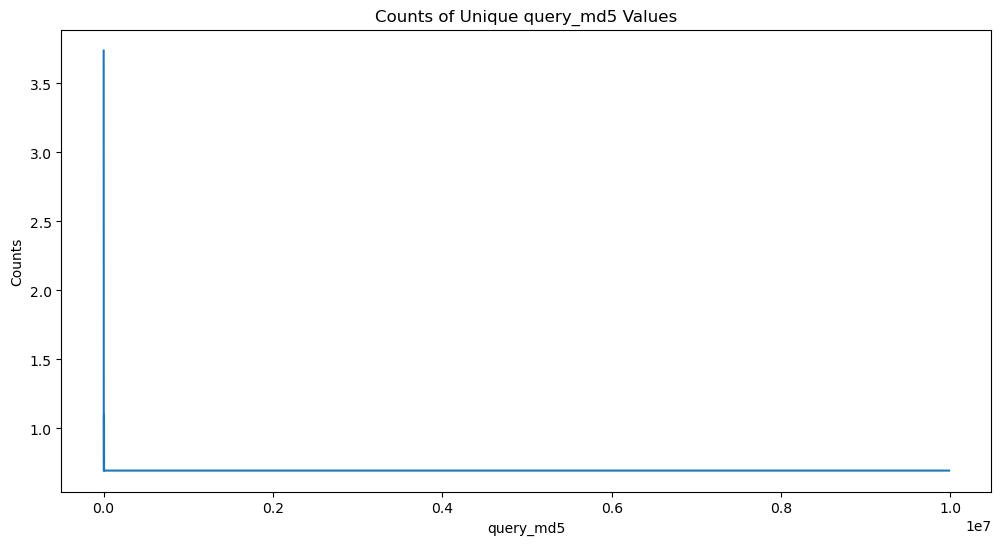

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Get unique values and their counts
unique_vals, counts = np.unique(ltr_table["media_type"].to_numpy(), return_counts=True)
unique_vals_count, counts_count = np.unique(counts, return_counts=True)
log_counts_count = np.log1p(counts_count)
# Create a bar plot
plt.figure(figsize=(12,6))
plt.plot(unique_vals_count, log_counts_count)

plt.xlabel("query_md5")
plt.ylabel("Counts")
plt.title("Counts of Unique query_md5 Values")
plt.show()